In [ ]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

notebook_dir = Path.cwd()
root_dir = notebook_dir.parent
sys.path.insert(0, str(root_dir))

import numpy as np
import pandas as pd
import random

from COMIND_transformer.model_generator import generate_logistic_model
from COMIND_transformer.synthetic_data_generator import generate_synthetic_data

from COMIND_transformer.visualization import *
from COMIND_transformer.utils import *

from COMIND_transformer.em_transformer import EM

np.set_printoptions(precision=4)

### Synthetic data generation

true x0: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
true f: [0.     0.0112 0.0121 0.0116 0.0269 0.     0.0102 0.     0.     0.    ]
a = 1.8531667261047913, b = 1.5312904682995265


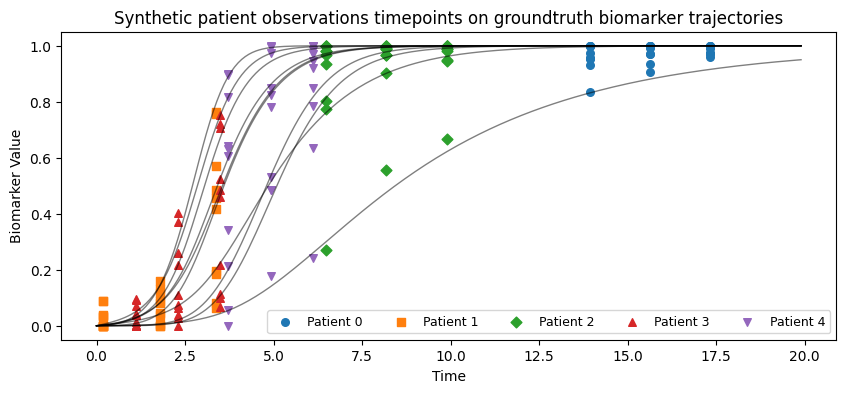

In [2]:
# params
n_biomarkers = 10
t_max = 20
t_span = np.linspace(0, t_max, 8000)
noise_level = 0.05
n_patients = 200
n_patient_obs = 3


t, x_true, K, x0, f, scalar_K  = generate_logistic_model(n_biomarkers=n_biomarkers, t_max=t_max)

df, cog_a, cog_b = generate_synthetic_data(
    n_biomarkers = n_biomarkers,
    t_max        = t_max, 
    noise_level  = noise_level,
    n_patients   = n_patients,
    n_patient_obs = n_patient_obs,
    x_true=x_true, 
    t=t,
)

plot_true_observations(df, t, x_true)

biomarker_cols = [col for col in df.columns if col.startswith("biomarker_")]

X_obs = df[biomarker_cols].values   # (n_obs, n_biomarkers)
dt = df["dt"].values                # (n_obs,)
ids = df["patient_id"].values       # (n_obs,)
cog = df["cognitive_score"].values  # (n_obs,)
beta_true = df["beta_true"].values  # (n_patients)

# print(X.shape, dt.shape, ids.shape, cog.shape, beta_true.shape)

def create_patient_list(X_obs, ids, dt, cog, initial_beta=None):
    unique_ids = np.unique(ids)
    id_to_index = {pid: idx for idx, pid in enumerate(unique_ids)}

    patient_list = []
    for pid in unique_ids:
        mask = (ids == pid)
        patient_data = {
            "id": pid,
            "X_obs": X_obs[mask],
            "dt": dt[mask],
            "cog": cog[mask],
        }
        if initial_beta is not None:
            patient_data["initial_beta"] = initial_beta[id_to_index[pid]]
        patient_list.append(patient_data)

    return patient_list

X = create_patient_list(X_obs, ids, dt, cog, initial_beta=None)
#X_train, X_val = train_test_split(X, test_size=0.2, random_state=75)

#print(X[0])

### COMIND transformer fit call

to fit model to data, we create an instance of the transformer class and call `fit(X, y=None)`
- `max iter`: is the number of times we loop fitter
- `t_max`: maximum time point for biomarker trajectories
- `K`: connectome derived transition matrix, its dimensions ought to be 'n_biomarkers x n_biomarkers'
- `lambda_f`: L1 regularization for f, the forcing term parameters.
- `lamda_cog`: # regularization weight for clinical score prior, our "priveledged biomarkers"
- `labda_scalar`: L2 regularization for scalar K

In [3]:
model = EM(max_iter=100,
             t_max=20,
             K=K, # transitions matrix
             lambda_f=0.545, 
             lambda_cog=0.0, 
             lambda_scalar=0.1, # 
             jac_toggle=True, # use jacobian for optimization
             epsilon=1e-4) # convergence threshold for early stopping, if subpar improvement then stop

model.fit(X, y=None);

  0%|          | 0/100 [00:00<?, ?it/s]

 41%|████      | 41/100 [05:57<08:34,  8.72s/it]


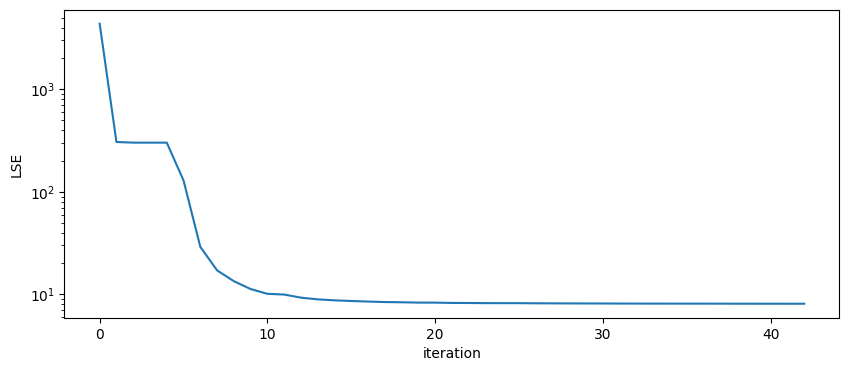

In [4]:
plot_lse(model.lse_history)


#### remap f back to original biom count

### COMIND Experiment w/ f initialization

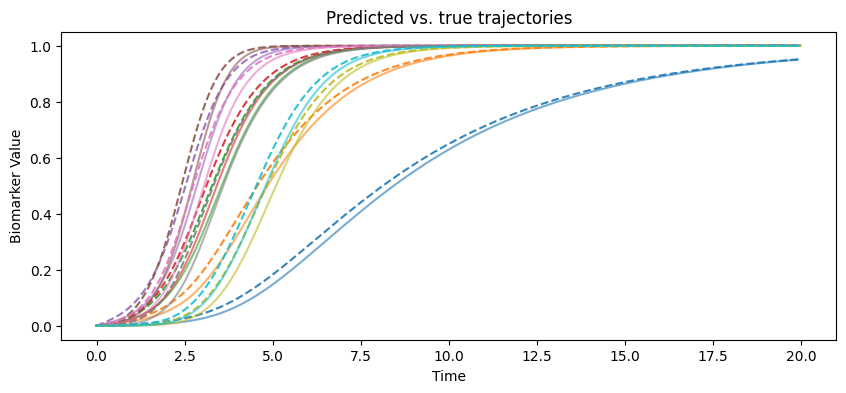

In [5]:
f_true = f 
s_true = np.ones(n_biomarkers)
scalar_K_true = 1.0 

#best_em = grid.best_estimator_

#plot_initial_beta_guess(df, em_model_0.beta_iter_, t, x_true)
# histories
theta_history = model.theta_history
beta_history = model.beta_history
lse_history = model.lse_history

# final params
final_theta = theta_history[:,-1]
final_x0 = np.zeros(n_biomarkers)
final_f = final_theta[0:n_biomarkers]
final_s = final_theta[n_biomarkers:2*n_biomarkers]
final_scalar_K = final_theta[-1]
final_model = solve_system(final_x0, final_f, K, t_span, final_scalar_K)

# initial parameters
initial_theta = theta_history[:,0]
initial_x0 = np.zeros(n_biomarkers)
initial_f = initial_theta[:n_biomarkers]
initial_s = initial_theta[n_biomarkers:2*n_biomarkers]
initial_scalar_K = initial_theta[-1]

scaled_final_model = np.zeros_like(final_model)
for idx, s in enumerate(final_s):
    scaled_final_model[idx, :] = s * final_model[idx, :]

initial_model = solve_system(initial_x0, initial_f, K, t_span, initial_scalar_K)

# plotting

plot_theta_fit_comparison(t, t_span, x_true, initial_model, final_model, n_biomarkers)
#plot_beta_overlay(df, beta_iter=, em_model_0.theta_iter_, t_span, n_biomarkers, x_init, x_final, iteration=em_model_0.num_iterations - 1)
#plot_beta_error_history(beta_history, em_model_0.num_iterations)
#plot_lse(lse_history)
#plot_cog_regression_history(em_model_0.cog_regression_history_)



In [6]:
print("THETA SUMMARY:")
print("true theta:")
print("f: ", np.round(f_true, 3))
print("s: ", np.round(s_true, 3))
print("s_k: ", scalar_K_true)

print("final theta:")
print("f: ", np.round(final_theta[:n_biomarkers], 3))
print("s: ", np.round(final_theta[n_biomarkers:2*n_biomarkers], 3))
print("s_k: ", final_theta[-1])

## Beta comparison:
print("\nBETA SUMMARY:")
beta_true = beta_true[::3]
print("beta true: ",np.round(beta_true,3)[0:10])
print("beta final: ", np.round(beta_history[0:10,-1], 3))

THETA SUMMARY:
true theta:
f:  [0.    0.011 0.012 0.012 0.027 0.    0.01  0.    0.    0.   ]
s:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
s_k:  1.0
final theta:
f:  [0.003 0.016 0.012 0.021 0.049 0.001 0.021 0.003 0.    0.001]
s:  [0.963 0.983 0.985 0.981 0.978 0.981 0.982 0.981 0.983 0.981]
s_k:  0.9738380845187629

BETA SUMMARY:
beta true:  [13.948  0.186  6.473  1.122  3.722 11.703 11.646  7.365 11.059 11.704]
beta final:  [17.934  0.     6.706  0.89   3.589 13.335 12.643  7.207 12.165 11.746]


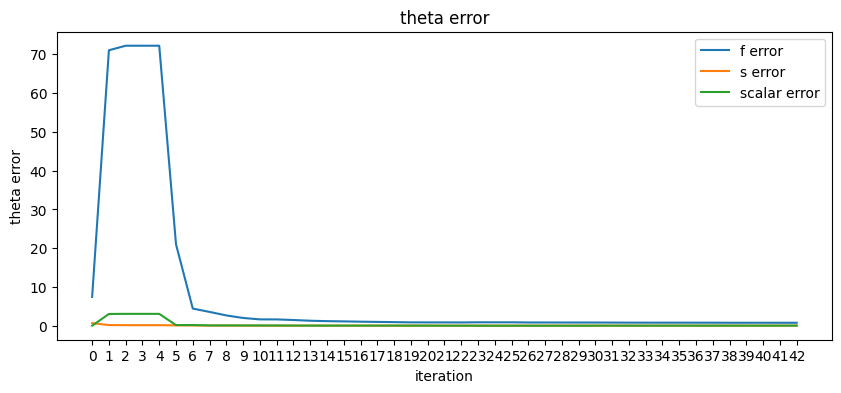

In [7]:
import matplotlib.pyplot as plt

def plot_theta_error_history(theta_history: np.ndarray, n_biomarkers: int,
                             f_true: np.ndarray, s_true: np.ndarray, scalar_K_true: float) -> None:
    """
    Plots normalized error of each parameter group over EM iterations.
    """
    num_iterations = theta_history.shape[1]
    f_error_history = []
    s_error_history = []
    scalar_K_error_history = []

    for iteration in range(num_iterations):
        theta = theta_history[:,iteration]

        f_est = theta[0:n_biomarkers]
        s_est = theta[n_biomarkers:2*n_biomarkers]
        scalar_K_est = theta[-1]

        f_err = np.mean(np.abs(f_true - f_est)) / (np.mean(np.abs(f_true)) + 1e-8)
        s_err = np.mean(np.abs(s_true - s_est)) / (np.mean(np.abs(s_true)) + 1e-8)
        k_err = np.abs(scalar_K_true - scalar_K_est) / (np.abs(scalar_K_true) + 1e-8)

        f_error_history.append(f_err)
        s_error_history.append(s_err)
        scalar_K_error_history.append(k_err)
        
    plt.figure(figsize=(10, 4))
    plt.plot(f_error_history, label="f error")
    plt.plot(s_error_history, label="s error")
    plt.plot(scalar_K_error_history, label="scalar error")
    plt.xticks(range(0,num_iterations))
    plt.title("theta error")
    plt.xlabel("iteration")
    plt.ylabel("theta error")
    plt.legend()
    plt.show()
    
plot_theta_error_history(theta_history=theta_history, n_biomarkers=n_biomarkers,
                         f_true=f, s_true=np.ones(n_biomarkers), scalar_K_true=scalar_K)

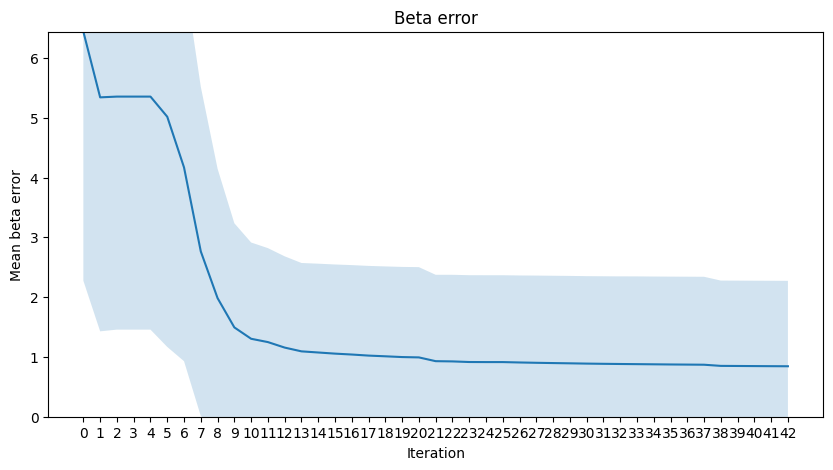

In [8]:
beta_true = df.groupby("patient_id")["beta_true"].first().values
plot_beta_error_history(beta_history, beta_true)

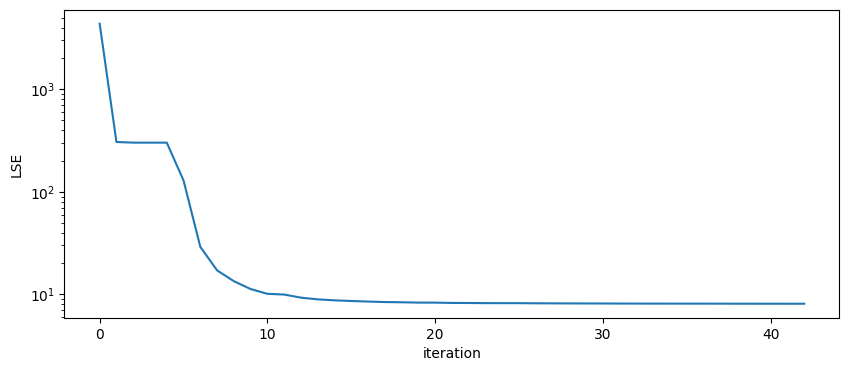

8.099532484183884


In [9]:
plot_lse(lse_history)
print(lse_history[-1])

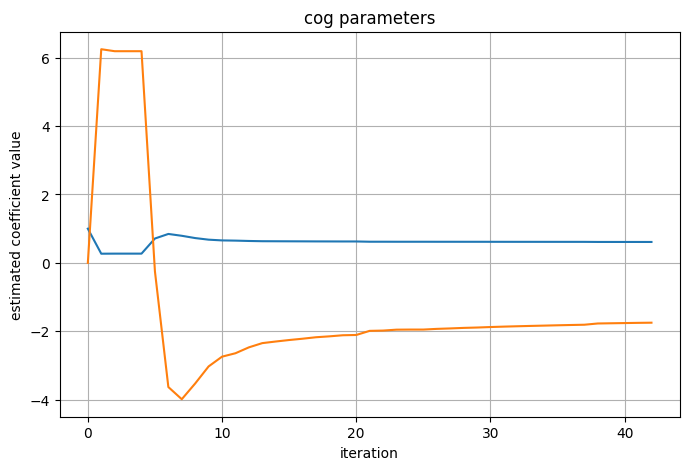

array([ 0.6115, -1.7493])

In [10]:
cog_true = np.array([cog_a, cog_b])

plot_cog_regression_history(model.cog_regression_history, cog_true)

model.cog_regression_history[:,-1]

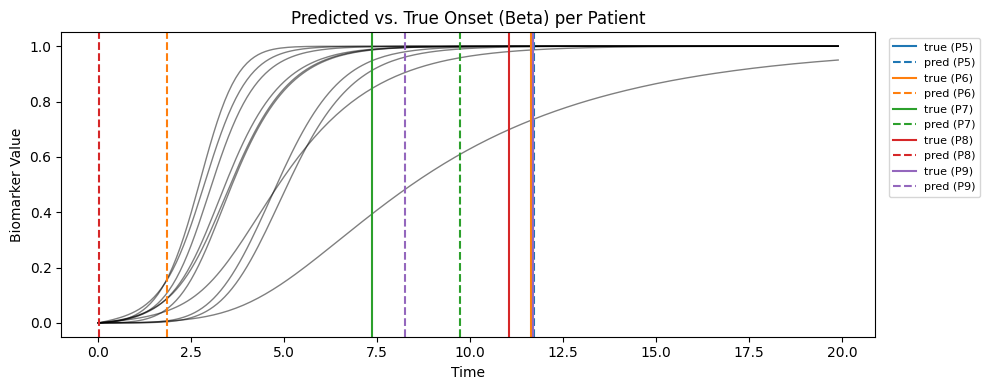

In [11]:
plot_beta_estimates_on_groundtruth(
    beta_history=beta_history,
    beta_true=beta_true,
    t=t,
    x_true=x_true,
    n_biomarkers=n_biomarkers,
    patient_idx=[5, 6, 7, 8, 9]
)